# In this note, we demonstrate the continual learning of the three-class tasks.

In [555]:
using Yao, YaoPlots
using LinearAlgebra, Statistics, Random, StatsBase, MAT, Printf
using Flux: batch, Flux
using Plots
include("3-class.jl") ; 

In [742]:
num_train = 500 ; num_test = 100 ;

num_qubit = 8 ;
depth = 9 ;
mid = Int(round(num_qubit/2)) ;

op0 = kron(num_qubit, mid=>0.5*(I2+Z), (mid+1)=>0.5*(I2+Z)  )  ;
op1 = kron(num_qubit, mid=>0.5*(I2-Z), (mid+1)=>0.5*(I2+Z)  ) ;
op2 = kron(num_qubit, mid=>0.5*(I2+Z), (mid+1)=>0.5*(I2-Z) ) ;

num_class = 3 ;

## Dataset

In [743]:
# data 1
data1 = matread("../dataset/FashionMNIST_1_5_8.mat")
x_train_1 = data1["x_train"][:,1:num_train] ;  y_train_1 = data1["y_train"][1:num_train,:] ;
x_test_1 = data1["x_test"][:,1:num_test] ;    y_test_1 = data1["y_test"][1:num_test, :] ;

x_train_1_yao = zero_state(num_qubit, nbatch = num_train)
x_train_1_yao.state = x_train_1 ;

x_test_1_yao = zero_state(num_qubit, nbatch = num_test)
x_test_1_yao.state = x_test_1 ;


# data 2
data2 = matread("../dataset/MNIST_1_4_8.mat") 

x_train_2 = data2["x_train"][:,1:num_train] ;  y_train_2 = data2["y_train"][1:num_train,:] ;
x_test_2 = data2["x_test"][:,1:num_test] ;    y_test_2 = data2["y_test"][1:num_test, :] ;

x_train_2_yao = zero_state(num_qubit, nbatch = num_train)
x_train_2_yao.state = x_train_2 ;

x_test_2_yao = zero_state(num_qubit, nbatch = num_test)
x_test_2_yao.state = x_test_2 ;

In [752]:
# random parameters
circuit = chain(chain(num_qubit, params_layer(num_qubit, 1:num_qubit), ent_cx(num_qubit, 1:num_qubit)) 
                    for _ in 1 : depth)  
dispatch!(circuit, :random);  ini_params = parameters(circuit);
# YaoPlots.plot(circuit)   

In [753]:
train_acc_1, train_loss_1 = acc_loss_evaluation_am(circuit, x_train_1_yao, y_train_1, num_train, mid)
test_acc_1, test_loss_1 = acc_loss_evaluation_am(circuit, x_test_1_yao, y_test_1, num_test, mid)

train_acc_2, train_loss_2 = acc_loss_evaluation_am(circuit, x_train_2_yao, y_train_2, num_train, mid)
test_acc_2, test_loss_2 = acc_loss_evaluation_am(circuit, x_test_2_yao, y_test_2, num_test, mid)

@printf("loss=%.3f, acc=%.3f, test_loss_1=%.3f,test_acc_1=%.3f\n",
                train_loss_1,train_acc_1,test_loss_1,test_acc_1) ;
@printf("loss=%.3f, acc=%.3f, test_loss_2=%.3f,test_acc_2=%.3f\n",
                train_loss_2,train_acc_2,test_loss_2,test_acc_2) ;

loss=0.509, acc=0.518, test_loss_1=0.518,test_acc_1=0.550
loss=0.504, acc=0.554, test_loss_2=0.484,test_acc_2=0.700


## training

In [754]:
# hyper-parameters
batch_size = 30       # batch size
lr1 = 0.01            # learning rate
niters = 40          # number of iterations
optim = Flux.NADAM(lr1)  # Adam optimizer

# record the training history
history_loss_train_1nd_1 = Float64[]
history_acc_train_1nd_1 = Float64[]
history_loss_test_1nd_1 = Float64[] ;
history_acc_test_1nd_1 = Float64[] ;

# grad_1_history = [] ; 
para_1_history = [] ;
# distance_history = Float64[] ;

para_1 = copy(ini_params);

In [755]:
for k in 1 : niters
    
    # calculate the accuracy, loss for the training and test set    
    test_acc_1, test_loss_1 = acc_loss_evaluation_am(circuit, x_test_1_yao, y_test_1, num_test, mid)

    push!(history_acc_test_1nd_1, test_acc_1)  ;     push!(history_loss_test_1nd_1, test_loss_1) ; 
    push!(para_1_history, para_1)
    
    @printf("\nStep=%d, test_loss_1=%.3f, test_acc_1=%.3f\n", k, test_loss_1, test_acc_1)

    if (test_acc_1 >= 0.94) && (test_loss_1 <= 0.25)
        break
    end
    
    batch_index_1 = randperm(num_train)[1 : batch_size]
    x_batch_1 = x_train_1[:, batch_index_1] ;   y_batch_1 = y_train_1[batch_index_1, :]   ;

    x_batch_1_ = copy(x_batch_1)
    x_batch_1_yao = zero_state(num_qubit, nbatch = batch_size)
    x_batch_1_yao.state = x_batch_1_;    
    
    batc_1 = [zero_state(num_qubit) for i in 1 : batch_size]
    for i in 1 : batch_size
        batc_1[i].state = x_batch_1_[:, i:i]
    end    
    
    q_1 = zeros(batch_size, num_class) ;   
    res = copy(x_batch_1_yao) |> circuit
    
    for i = 1 : batch_size
        rdm = density_matrix(viewbatch(res, i), (mid,mid+1))
        q_1[i,:] = Yao.probs(rdm)[1:num_class]
        q_1[i,:] = q_1[i,:]/ norm(q_1[i,:])
    end
    
    # calculate the gradients 
    Arr11 = Array{Float64}( zeros(batch_size, nparameters(circuit) ) )
    Arr12 =  Array{Float64}( zeros(batch_size, nparameters(circuit) ) )
    Arr13 =  Array{Float64}( zeros(batch_size, nparameters(circuit) ) )
    
    for i in 1 : batch_size
        Arr11[i,:] = expect'(op0, copy(batc_1[i])=>circuit)[2]
        Arr12[i,:] = expect'(op1, copy(batc_1[i])=>circuit)[2]
        Arr13[i,:] = expect'(op2, copy(batc_1[i])=>circuit)[2]
    end
    
    C_1 = [Arr11, Arr12, Arr13]

    grad_1 = collect( mean( [-sum([y_batch_1[i,j]*((1 ./ q_1)[i,j])*batch(C_1)[i,:,j] for j in 1:num_class]) 
                    for i = 1 : batch_size] ) )   
            
    # update the parameters
    updates = Flux.Optimise.update!(optim, copy(para_1), grad_1);
    para_1 = updates
    
    # update the parameters
    dispatch!(circuit, para_1) 

end


Step=1, test_loss_1=0.518, test_acc_1=0.550

Step=2, test_loss_1=0.478, test_acc_1=0.610

Step=3, test_loss_1=0.443, test_acc_1=0.640

Step=4, test_loss_1=0.415, test_acc_1=0.660

Step=5, test_loss_1=0.389, test_acc_1=0.750

Step=6, test_loss_1=0.366, test_acc_1=0.850

Step=7, test_loss_1=0.345, test_acc_1=0.840

Step=8, test_loss_1=0.327, test_acc_1=0.840

Step=9, test_loss_1=0.324, test_acc_1=0.820

Step=10, test_loss_1=0.310, test_acc_1=0.840

Step=11, test_loss_1=0.300, test_acc_1=0.840

Step=12, test_loss_1=0.301, test_acc_1=0.840

Step=13, test_loss_1=0.301, test_acc_1=0.830

Step=14, test_loss_1=0.297, test_acc_1=0.830

Step=15, test_loss_1=0.284, test_acc_1=0.830

Step=16, test_loss_1=0.278, test_acc_1=0.810

Step=17, test_loss_1=0.283, test_acc_1=0.850

Step=18, test_loss_1=0.270, test_acc_1=0.830

Step=19, test_loss_1=0.267, test_acc_1=0.810

Step=20, test_loss_1=0.269, test_acc_1=0.860

Step=21, test_loss_1=0.270, test_acc_1=0.860

Step=22, test_loss_1=0.259, test_acc_1=0.8

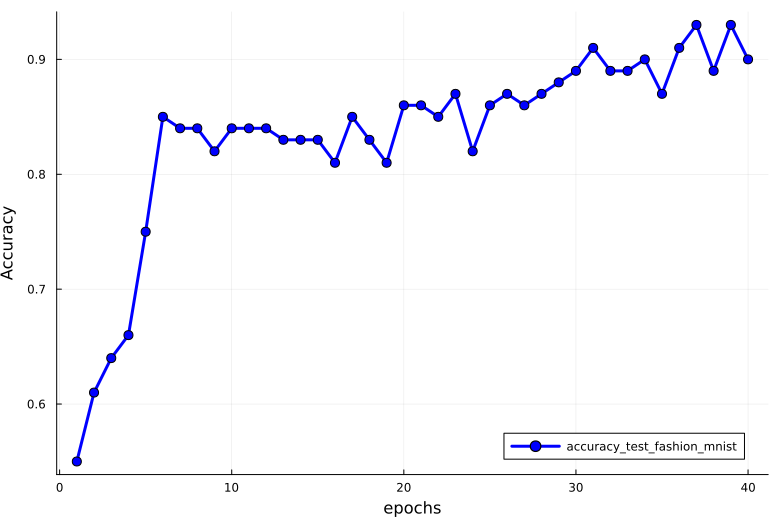

In [756]:
Plots.plot(history_acc_test_1nd_1, color = :blue, marker = :circle, lw=3, markersize = 5, size=(6*130,4*130), 
        ylabel="Accuracy", xlabel="epochs", label="accuracy_test_fashion_mnist", legend = :bottomright) 

In [757]:
fim1 = fisher_am(circuit, x_train_1_yao, y_train_1, num_train, mid) ;

In [762]:
history_acc_train_2nd_2 = Float64[] ;   history_acc_test_2nd_2 = Float64[] ;
history_loss_train_2nd_2 = Float64[] ;   history_loss_test_2nd_2 = Float64[] ;

history_acc_test_2nd_1 = Float64[] ;   history_loss_test_2nd_1 = Float64[] ;

para_2_history = [] ;

In [763]:
para_2 = copy(para_1_history[end])  ;
dispatch!(circuit, para_2) ;

In [764]:
# hyper-parameters
batch_size = 30       # batch size
lr2 = 0.01         # learning rate
niters2 = 40          # number of iterations
optim2 = Flux.NADAM(lr2) ;# Adam optimizer  

lambda = 80;

In [765]:
for k in 1 : niters2
    
    # calculate the accuracy and loss for the test set    
    acc_test_2nd_2, loss_test_2nd_2 = acc_loss_evaluation_am(circuit, x_test_2_yao, y_test_2, num_test, mid)
    acc_test_2nd_1, loss_test_2nd_1 = acc_loss_evaluation_am(circuit, x_test_1_yao, y_test_1, num_test, mid)
    
    push!(history_acc_test_2nd_2, acc_test_2nd_2) ;    push!(history_loss_test_2nd_2, loss_test_2nd_2) ;   
    push!(history_acc_test_2nd_1, acc_test_2nd_1) ;    push!(history_loss_test_2nd_1, loss_test_2nd_1) ;  
    push!(para_2_history, copy(para_2)) ;    
    
    @printf("Step=%d, test_loss=%.3f,test_acc=%.3f\n", k, loss_test_2nd_2, acc_test_2nd_2)
    @printf("task1, loss=%.3f, acc=%.3f\n", loss_test_2nd_1, acc_test_2nd_1)

    if (acc_test_2nd_2 >= 0.9) && (acc_test_2nd_1 > 0.85)
        break
    end
    
    batch_index = randperm(num_train)[1 : batch_size]
    x_batch_2 = x_train_2[:, batch_index] ;   y_batch_2 = y_train_2[batch_index, :]   ;

    x_batch_2_ = copy(x_batch_2)
    x_batch_2_yao = zero_state(num_qubit, nbatch = batch_size)
    x_batch_2_yao.state = x_batch_2_;    
    
    batc_2 = [zero_state(num_qubit) for i in 1 : batch_size]
    for i in 1 : batch_size
        batc_2[i].state = x_batch_2_[:, i:i]
    end    
    
    q_2 = zeros(batch_size, num_class) ;   
    res_2 = copy(x_batch_2_yao) |> circuit
    
    for i = 1 : batch_size
        rdm = density_matrix(viewbatch(res_2, i), (mid, mid+1))
        q_2[i,:] = Yao.probs(rdm)[1 : num_class]
        q_2[i,:] = q_2[i,:]/ norm(q_2[i,:])
    end
    
    # calculate the gradients 
    Arr21 = Array{Float64}( zeros(batch_size, nparameters(circuit) ) )
    Arr22 =  Array{Float64}( zeros(batch_size, nparameters(circuit) ) )
    Arr23 =  Array{Float64}( zeros(batch_size, nparameters(circuit) ) )
    
    for i in 1 : batch_size
        Arr21[i,:] = expect'(op0, copy(batc_2[i])=>circuit)[2]
        Arr22[i,:] = expect'(op1, copy(batc_2[i])=>circuit)[2]
        Arr23[i,:] = expect'(op2, copy(batc_2[i])=>circuit)[2]
    end
    
    C_2 = [Arr21, Arr22, Arr23]

    grad_2 = collect( mean( [-sum([y_batch_2[i,j]*((1 ./ q_2)[i,j])*batch(C_2)[i,:,j] for j in 1:num_class]) 
                    for i = 1 : batch_size] ) )   

    grad = grad_2 + lambda * fim1 .* (para_2 - para_1)            
        
    # update the parameters
    updates = Flux.Optimise.update!(optim2, copy(para_2), grad);
    para_2 = updates
    
    # update the parameters
    dispatch!(circuit, copy(para_2)) 
    
end

Step=1, test_loss=0.591,test_acc=0.230
task1, loss=0.228, acc=0.900
Step=2, test_loss=0.568,test_acc=0.310
task1, loss=0.229, acc=0.920
Step=3, test_loss=0.537,test_acc=0.450
task1, loss=0.239, acc=0.960
Step=4, test_loss=0.515,test_acc=0.450
task1, loss=0.252, acc=0.930
Step=5, test_loss=0.501,test_acc=0.520
task1, loss=0.261, acc=0.940
Step=6, test_loss=0.488,test_acc=0.560
task1, loss=0.266, acc=0.940
Step=7, test_loss=0.476,test_acc=0.620
task1, loss=0.267, acc=0.950
Step=8, test_loss=0.454,test_acc=0.690
task1, loss=0.287, acc=0.920
Step=9, test_loss=0.438,test_acc=0.740
task1, loss=0.304, acc=0.890
Step=10, test_loss=0.437,test_acc=0.740
task1, loss=0.298, acc=0.880
Step=11, test_loss=0.440,test_acc=0.700
task1, loss=0.285, acc=0.910
Step=12, test_loss=0.422,test_acc=0.780
task1, loss=0.302, acc=0.890
Step=13, test_loss=0.428,test_acc=0.700
task1, loss=0.291, acc=0.940
Step=14, test_loss=0.428,test_acc=0.700
task1, loss=0.292, acc=0.940
Step=15, test_loss=0.403,test_acc=0.820
tas

In [766]:
acc_task1 = vcat(history_acc_test_1nd_1, history_acc_test_2nd_1) ;
acc_task2 = vcat(history_acc_test_2nd_2) ;
length_1 = length(history_acc_test_1nd_1) ;
length_2 = length(history_acc_test_2nd_1) ;
length_ = [length_1, length_2] ;

loss_task1 = vcat(history_loss_test_1nd_1, history_loss_test_2nd_1) ;
loss_task2 = vcat(history_loss_test_2nd_2) ;

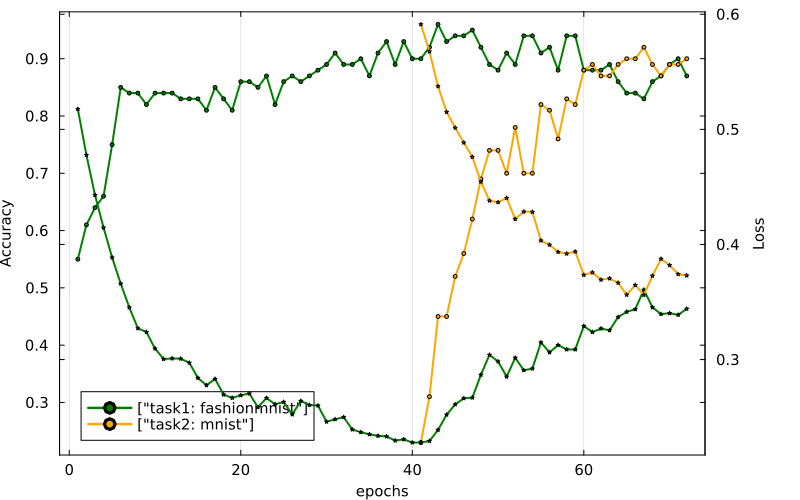

In [769]:
Plots.plot(acc_task1, color= :green, label = ["task1: fashionmnist"], marker=:o, markersize = 2, lw=2, 
       legend = :bottomright, ylabel="Accuracy", xlabel="epochs", right_margin = 1cm, left_margin = 0.1cm, top_margin = 0.1cm ) 

Plots.plot!(length_[1]+1 : sum(length_), acc_task2, color= :orange, marker=:o, markersize = 2, label = ["task2: mnist"], 
      lw=2, legend = :bottomleft) 

p = Plots.twinx() ;

Plots.plot!(p, loss_task1, color= :green, label = ["task1: quantum data"], marker=:star, markersize = 2, lw=2, size=(8*100, 5*100), 
                legend=:none, ylabel="Loss") 
Plots.plot!(p, length_[1]+1 : sum(length_), loss_task2, color= :orange, marker=:star,  markersize = 2, label = ["task2: quantum data"], 
       lw=2, legend=:none, size=(8*100, 5*100) )

size = 10
Plots.plot!( xtickfontsize = size, ytickfontsize=size, xguidefontsize=size, yguidefontsize=size , 
                legendfontsize=size, titlefontsize = size, legendfont=font(7), framestyle=:box  ) 

In [768]:
matwrite("EWC_three_class-mnist&fashion.mat", Dict(
        "acc_task1" => acc_task1,
        "acc_task2" => acc_task2,
        "length_" => length_,
        "loss_task1" => loss_task1, 
         "loss_task2" => loss_task2,
         "para_1_history" => para_1_history,
         "para_2_history" => para_2_history,      
        "fisher_information" => real(fim1)
)
        )

In [ ]:
# Plots.savefig("figures/Loss_Multiple-task-learning_15qubits.pdf")